# Modul 3: Optimizer dan Strategi Pelatihan

**Nama:** Fadil Alfarizzi  
**NIM:** 123450048  
**Kelas:** RC  
**Tanggal:** 2026-09-28  

Simpan berkas ini sebagai `M03_NIM.ipynb` sebelum mulai mengerjakan.

## Petunjuk

1. Ganti seluruh penanda `TODO`. Jangan menghapus sel pemeriksaan.
2. Protokol modul tetap: subset $12\,000$/$3\,000$, model $784 \rightarrow 128 \rightarrow 10$, batch $128$, $5$ epoch. Ubah **hanya** faktor yang sedang diuji.
3. Seluruh run wajib memanggil fungsi `jalankan()` yang sama.
4. Pilih model dari validation loss. Data uji dipakai **satu kali** di akhir.
5. Catat setiap run ke `metrics.csv`, termasuk run yang gagal.
6. Luaran: `M03_NIM.ipynb`, `M03_NIM.pdf`, `M03_NIM_metrics.csv`, dan grafik perbandingan.

In [1]:
import platform
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
from torchvision.datasets import FashionMNIST

NIM = '123450048'                     # contoh: '120450123'
SEED = int(str(NIM)[-4:]) if str(NIM).isdigit() else 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
pd.set_option('display.precision', 4)
print({'python': platform.python_version(), 'torch': torch.__version__,
       'device': str(DEVICE), 'seed': SEED})

{'python': '3.11.15', 'torch': '2.14.0+cu130', 'device': 'cpu', 'seed': 48}


## A. Pre-lab - 10 poin

Jawab sebelum sesi praktikum dimulai.

1. **Jumlah update satu epoch bila $n=12\,000$ dan batch $=128$:** $\lceil 12\,000/128 \rceil = \lceil 93{,}75 \rceil = 94$ update, yaitu 93 batch penuh berisi 128 sampel dan satu batch terakhir berisi 96 sampel. Untuk 5 epoch berarti 470 update.
2. **Apa itu derau gradien pada mini-batch, dan mengapa full-batch tidak memilikinya:** gradien mini-batch adalah estimasi gradien seluruh data yang dihitung dari sebagian sampel saja, sehingga nilainya berubah-ubah tergantung sampel yang terambil. Selisih antara estimasi ini dan gradien sebenarnya disebut derau gradien, dan variansnya mengecil kira-kira sebanding $1/B$. Full-batch menghitung gradien dari seluruh data latih, sehingga untuk parameter yang sama hasilnya selalu sama persis dan tidak ada komponen acak dari pengambilan sampel.
3. **Mengapa membandingkan dua optimizer pada learning rate yang sama belum tentu adil:** arti angka learning rate berbeda antaroptimizer. Pada SGD, langkahnya $\eta \cdot g$, sehingga besar langkah ikut skala gradien. Momentum $0{,}9$ memperbesar langkah efektif sekitar $1/(1-\beta)=10$ kali. Adam menormalkan gradien per parameter dengan $\sqrt{\hat v}$, sehingga langkahnya kira-kira sebesar $\eta$ saja. Satu nilai $\eta$ bisa terlalu kecil untuk satu optimizer tetapi terlalu besar untuk yang lain. Perbandingan yang adil adalah membandingkan hasil terbaik masing-masing optimizer pada grid learning rate-nya sendiri.
4. **Perkiraan bentuk kurva loss bila learning rate dinaikkan sepuluh kali:** loss awalnya turun lebih cepat, tetapi kemudian berosilasi atau zig-zag dan tertahan pada nilai yang lebih tinggi karena langkahnya melewati lembah minimum. Bila kenaikannya melewati batas stabil, loss justru naik atau meledak menjadi `nan` dalam beberapa update pertama.

**Hipotesis awal.** Optimizer mana yang Anda perkirakan menang, dan atas dasar apa? Saya memperkirakan Adam dengan $\eta=10^{-3}$ menang pada anggaran 5 epoch. Alasannya, langkah adaptif per parameter membuatnya cepat turun tanpa perlu menyetel skala gradien, sementara SGD biasa paling lambat. SGD+momentum diperkirakan mendekati Adam bila learning rate-nya tepat.

## B. Data dan protokol - 15 poin

Ambil subset terstratifikasi dan hitung statistik normalisasi **hanya** dari subset latih.

In [2]:
DATA_ROOT = Path('../../data/raw')
if not DATA_ROOT.exists():
    DATA_ROOT = Path('data/raw')

latih_penuh = FashionMNIST(root=DATA_ROOT, train=True, download=False,
                           transform=transforms.ToTensor())
uji_resmi = FashionMNIST(root=DATA_ROOT, train=False, download=False,
                         transform=transforms.ToTensor())

X_penuh = latih_penuh.data.float().unsqueeze(1) / 255.0
y_penuh = latih_penuh.targets
X_uji = uji_resmi.data.float().unsqueeze(1) / 255.0
y_uji = uji_resmi.targets

# Ambil 12.000 latih dan 3.000 validasi secara terstratifikasi
# memakai train_test_split dengan random_state=SEED.
idx_latih, idx_val = train_test_split(
    np.arange(len(y_penuh)), train_size=12_000, test_size=3_000,
    stratify=y_penuh.numpy(), random_state=SEED)

X_latih, y_latih = X_penuh[idx_latih], y_penuh[idx_latih]
X_val, y_val = X_penuh[idx_val], y_penuh[idx_val]

# Hitung MEAN dan STD dari subset LATIH saja, lalu normalkan ketiga split.
MEAN, STD = X_latih.mean().item(), X_latih.std().item()
normalkan = lambda t: (t - MEAN) / STD

ds_latih = TensorDataset(normalkan(X_latih), y_latih)
ds_val = TensorDataset(normalkan(X_val), y_val)
ds_uji = TensorDataset(normalkan(X_uji), y_uji)

print(f'latih {len(ds_latih)}  validasi {len(ds_val)}  uji {len(ds_uji)}')
print('distribusi kelas latih:', torch.bincount(y_latih).tolist())

# Pemeriksaan wajib.
assert (len(ds_latih), len(ds_val), len(ds_uji)) == (12_000, 3_000, 10_000)
assert torch.bincount(y_latih).min().item() == 1_200, 'subset harus terstratifikasi'
print('split sesuai protokol')

latih 12000  validasi 3000  uji 10000


distribusi kelas latih: [1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200]
split sesuai protokol


In [3]:
BATCH = 128
EPOCH = 5

def buat_model():
    """Kembalikan model 784 -> 128 -> 10 yang SELALU dimulai dari seed sama."""
    torch.manual_seed(SEED)
    model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 128),
        nn.ReLU(),
        nn.Linear(128, 10),
    )
    return model.to(DEVICE)

def buat_optimizer(nama, params, lr):
    """Kembalikan SGD, SGD+momentum 0.9, atau Adam sesuai nama."""
    if nama == 'sgd':
        return torch.optim.SGD(params, lr=lr)
    if nama == 'momentum':
        return torch.optim.SGD(params, lr=lr, momentum=0.9)
    if nama == 'adam':
        return torch.optim.Adam(params, lr=lr)
    raise ValueError(f'optimizer tidak dikenal: {nama}')

def loader(ds, batch, acak):
    g = torch.Generator().manual_seed(SEED)
    return DataLoader(ds, batch_size=batch, shuffle=acak, generator=g if acak else None)

@torch.no_grad()
def evaluasi(model, ds, batch=512):
    model.eval()
    kriteria = nn.CrossEntropyLoss(reduction='sum')
    total_loss, benar = 0.0, 0
    for xb, yb in loader(ds, batch, False):
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = model(xb)
        total_loss += kriteria(logits, yb).item()
        benar += (logits.argmax(1) == yb).sum().item()
    return total_loss / len(ds), benar / len(ds)

jumlah_parameter = sum(p.numel() for p in buat_model().parameters())
print('jumlah parameter:', jumlah_parameter)
assert jumlah_parameter == 101_770, 'arsitektur belum sesuai protokol'

jumlah parameter: 101770


In [4]:
def jalankan(nama_opt, lr, batch=BATCH, epoch=EPOCH, scheduler=None):
    """Satu fungsi pelatihan untuk SELURUH run.

    Wajib mengembalikan (model, riwayat, catatan) dengan:
      riwayat : dict berisi list train_loss, val_loss, val_acc per epoch
      catatan : dict satu baris metrics.csv, memuat sekurangnya run_id, seed,
                optimizer, learning_rate, scheduler, batch_size, n_update,
                train_loss, val_loss, val_acc, grad_norm_mean, runtime_s
    Jangan lupa zero_grad -> backward -> step, dan catat norma gradien
    sebelum step.

    Scheduler diperbarui per epoch: 'step' = StepLR(step_size=2, gamma=0.5),
    'cosine' = CosineAnnealingLR(T_max=epoch).
    """
    model = buat_model()
    opt = buat_optimizer(nama_opt, model.parameters(), lr)
    if scheduler is None:
        sched = None
    elif scheduler == 'step':
        sched = torch.optim.lr_scheduler.StepLR(opt, step_size=2, gamma=0.5)
    elif scheduler == 'cosine':
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epoch)
    else:
        raise ValueError(f'scheduler tidak dikenal: {scheduler}')
    kriteria = nn.CrossEntropyLoss()
    dl = loader(ds_latih, batch, True)

    riwayat = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'grad_norm': []}
    n_update, status = 0, 'ok'
    t0 = time.perf_counter()
    for _ in range(epoch):
        model.train()
        total, n, norma_epoch = 0.0, 0, []
        for xb, yb in dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = kriteria(model(xb), yb)
            loss.backward()
            norma = torch.sqrt(sum((p.grad.detach() ** 2).sum()
                                   for p in model.parameters())).item()
            opt.step()
            n_update += 1
            total += loss.item() * len(yb)
            n += len(yb)
            norma_epoch.append(norma)
        if sched is not None:
            sched.step()
        val_loss, val_acc = evaluasi(model, ds_val)
        riwayat['train_loss'].append(total / n)
        riwayat['val_loss'].append(val_loss)
        riwayat['val_acc'].append(val_acc)
        riwayat['grad_norm'].append(float(np.mean(norma_epoch)))
        if not (np.isfinite(total / n) and np.isfinite(val_loss)):
            status = 'divergen'
            break
    runtime = time.perf_counter() - t0

    run_id = f'{nama_opt}_lr{lr:g}'
    if scheduler:
        run_id += f'_{scheduler}'
    if batch != BATCH:
        run_id += f'_b{batch}'
    catatan = {
        'run_id': run_id, 'seed': SEED, 'dataset': 'FashionMNIST',
        'split': '12000/3000/10000', 'model': 'MLP_784-128-10',
        'optimizer': nama_opt, 'learning_rate': lr,
        'scheduler': scheduler or 'none', 'batch_size': batch,
        'epochs': len(riwayat['val_loss']), 'n_update': n_update,
        'train_loss': riwayat['train_loss'][-1], 'val_loss': riwayat['val_loss'][-1],
        'val_acc': riwayat['val_acc'][-1],
        'grad_norm_mean': float(np.nanmean(riwayat['grad_norm'])),
        'runtime_s': runtime, 'parameters': jumlah_parameter,
        'device': str(DEVICE), 'status': status,
    }
    return model, riwayat, catatan

## C. Baseline dan tiga learning rate - bagian dari 25 poin

Jalankan SGD pada $\eta \in \{0{,}001;\;0{,}1;\;1{,}0\}$, tampilkan ketiga kurva dalam satu grafik, lalu cocokkan dengan tabel gejala pada modul.

lr=0.001  train_loss/epoch: [2.163, 1.909, 1.704, 1.532, 1.39]  val_loss/epoch: [2.022, 1.798, 1.613, 1.459, 1.334]


lr=0.1  train_loss/epoch: [0.788, 0.517, 0.466, 0.436, 0.402]  val_loss/epoch: [0.671, 0.495, 0.474, 0.455, 0.432]


lr=1  train_loss/epoch: [2.431, 1.98, 2.049, 1.964, 1.958]  val_loss/epoch: [1.672, 1.685, 2.242, 2.053, 1.721]
       run_id  train_loss  val_loss  val_acc  grad_norm_mean status
C_sgd_lr0.001      1.3901    1.3345    0.660          1.7606     ok
  C_sgd_lr0.1      0.4015    0.4324    0.841          1.3393     ok
    C_sgd_lr1      1.9576    1.7206    0.330          1.3699     ok


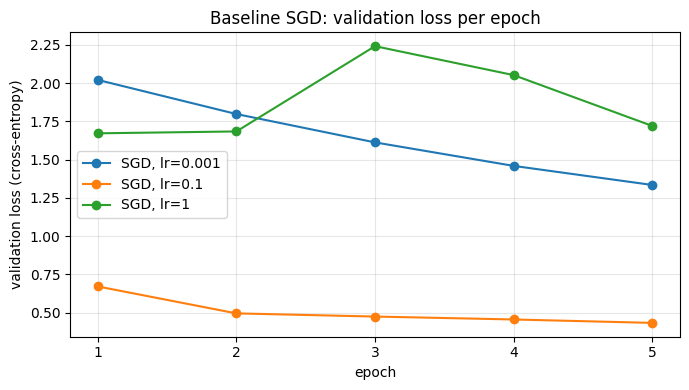

In [5]:
# Jalankan tiga learning rate, kumpulkan catatan dan riwayatnya,
# lalu tampilkan satu grafik validation loss berlabel lengkap.
baseline, riwayat_baseline = [], {}
for lr in [0.001, 0.1, 1.0]:
    _, riw, cat = jalankan('sgd', lr)
    cat['run_id'] = f'C_sgd_lr{lr:g}'
    cat['notes'] = 'baseline learning rate'
    baseline.append(cat)
    riwayat_baseline[lr] = riw
    print(f'lr={lr:g}  train_loss/epoch:', np.round(riw['train_loss'], 3).tolist(),
          ' val_loss/epoch:', np.round(riw['val_loss'], 3).tolist())

df_baseline = pd.DataFrame(baseline)
print(df_baseline[['run_id', 'train_loss', 'val_loss', 'val_acc',
                   'grad_norm_mean', 'status']].to_string(index=False))

epoch_ax = np.arange(1, EPOCH + 1)
fig, ax = plt.subplots(figsize=(7, 4))
for lr, riw in riwayat_baseline.items():
    ax.plot(epoch_ax[:len(riw['val_loss'])], riw['val_loss'], marker='o',
            label=f'SGD, lr={lr:g}')
ax.set(title='Baseline SGD: validation loss per epoch', xlabel='epoch',
       ylabel='validation loss (cross-entropy)')
ax.set_xticks(epoch_ax)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

**Pembacaan kurva.** Cocokkan setiap kurva dengan gejala pada modul dan sebutkan pula nilai `grad_norm_mean`-nya:

- $\eta=0{,}001$: kurva turun sangat lambat dan hampir lurus. Validation loss hanya turun dari 2,022 ke 1,335 dalam 5 epoch, dan akurasi validasi baru 0,660. Ini gejala **learning rate terlalu kecil**: arahnya benar tetapi model belum konvergen. `grad_norm_mean` = 1,761, paling tinggi dari ketiga run dan menurun pelan (2,03 ke 1,54 per epoch). Gradien masih besar karena model masih jauh dari minimum, tetapi langkah $\eta \cdot g$ terlalu kecil untuk memanfaatkannya.
- $\eta=0{,}1$: loss turun tajam pada epoch 1-2 (validation loss 0,671 ke 0,495), lalu melandai mulus sampai 0,432. Train loss (0,402) dan validation loss berdekatan, dan akurasi validasi 0,841. Ini gejala **learning rate tepat**: cepat di awal lalu stabil tanpa osilasi. `grad_norm_mean` = 1,339.
- $\eta=1{,}0$: validation loss zig-zag (1,672, 1,685, 2,242, 2,053, 1,721) dan train loss tertahan di kisaran 1,96-2,05, dekat loss tebakan acak $\ln 10 \approx 2{,}30$. Train loss epoch pertama (2,431) bahkan lebih buruk dari tebakan acak. Akurasi validasi hanya 0,330. Ini gejala **learning rate terlalu besar**: langkahnya melompati lembah minimum sehingga loss berosilasi dan tidak konvergen, walaupun belum meledak menjadi `nan`. `grad_norm_mean` = 1,370, hampir sama dengan $\eta=0{,}1$. Jadi yang membedakan bukan besar gradiennya, melainkan besar langkah $\eta\lVert g \rVert$ yang sepuluh kali lebih besar.

## D. Sembilan run terkendali - 25 poin

Setiap optimizer diuji pada tiga learning rate-nya sendiri. Model diinisialisasi ulang dari seed yang sama sebelum setiap run.

In [6]:
grid = {'sgd': [0.01, 0.1, 0.5],
        'momentum': [0.01, 0.05, 0.1],
        'adam': [1e-4, 1e-3, 1e-2]}

# Jalankan seluruh kombinasi, simpan ke daftar `hasil`
# dan riwayat tiap run ke dict `riwayat_semua`.
hasil, riwayat_semua = [], {}
for nama_opt, daftar_lr in grid.items():
    for lr in daftar_lr:
        _, riw, cat = jalankan(nama_opt, lr)
        cat['run_id'] = f'D_{nama_opt}_lr{lr:g}'
        cat['notes'] = 'grid optimizer x learning rate'
        hasil.append(cat)
        riwayat_semua[(nama_opt, lr)] = riw
        print(f"{cat['run_id']:<18} val_loss/epoch:", np.round(riw['val_loss'], 3).tolist())

tabel = pd.DataFrame(hasil)
print(tabel[['run_id', 'optimizer', 'learning_rate', 'val_loss', 'val_acc',
             'runtime_s']].sort_values('val_loss').to_string(index=False))
assert len(tabel) == 9, 'harus ada sembilan run inti'

D_sgd_lr0.01       val_loss/epoch: [0.994, 0.771, 0.685, 0.635, 0.6]


D_sgd_lr0.1        val_loss/epoch: [0.671, 0.495, 0.474, 0.455, 0.432]


D_sgd_lr0.5        val_loss/epoch: [0.829, 0.534, 0.599, 0.494, 0.64]


D_momentum_lr0.01  val_loss/epoch: [0.573, 0.502, 0.451, 0.453, 0.43]


D_momentum_lr0.05  val_loss/epoch: [0.486, 0.458, 0.483, 0.417, 0.399]


D_momentum_lr0.1   val_loss/epoch: [0.566, 0.562, 0.526, 0.572, 0.593]


D_adam_lr0.0001    val_loss/epoch: [0.892, 0.688, 0.608, 0.564, 0.533]


D_adam_lr0.001     val_loss/epoch: [0.509, 0.464, 0.423, 0.432, 0.404]


D_adam_lr0.01      val_loss/epoch: [0.504, 0.431, 0.514, 0.443, 0.454]
           run_id optimizer  learning_rate  val_loss  val_acc  runtime_s
D_momentum_lr0.05  momentum         0.0500    0.3988   0.8627     1.1263
   D_adam_lr0.001      adam         0.0010    0.4042   0.8573     1.2164
D_momentum_lr0.01  momentum         0.0100    0.4298   0.8503     0.9771
      D_sgd_lr0.1       sgd         0.1000    0.4324   0.8410     1.1164
    D_adam_lr0.01      adam         0.0100    0.4540   0.8480     1.2027
  D_adam_lr0.0001      adam         0.0001    0.5325   0.8133     1.2282
 D_momentum_lr0.1  momentum         0.1000    0.5931   0.8160     1.3318
     D_sgd_lr0.01       sgd         0.0100    0.6000   0.7950     0.9511
      D_sgd_lr0.5       sgd         0.5000    0.6401   0.7433     1.1258


## E. Memilih model dan evaluasi akhir - 20 poin

Pilih learning rate terbaik tiap optimizer dari **validation loss**, bandingkan ketiga pemenang, lalu evaluasi data uji **satu kali** pada satu model final.

           run_id optimizer  learning_rate  val_loss  val_acc  runtime_s
D_momentum_lr0.05  momentum          0.050    0.3988   0.8627     1.1263
   D_adam_lr0.001      adam          0.001    0.4042   0.8573     1.2164
      D_sgd_lr0.1       sgd          0.100    0.4324   0.8410     1.1164


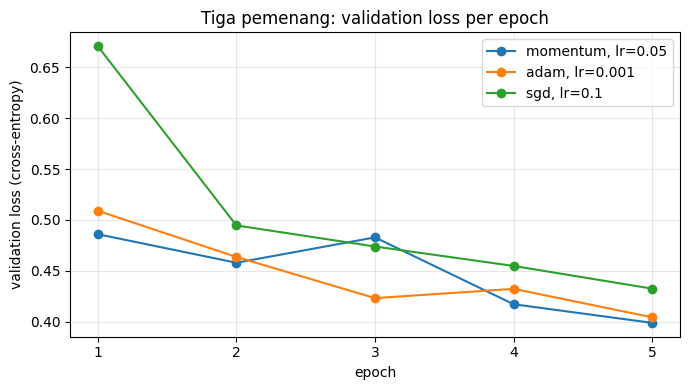

In [7]:
# Tentukan pemenang tiap optimizer, tampilkan tabel perbandingan
# (val_loss, val_acc, runtime_s) dan satu grafik tiga kurva.
pemenang = (tabel.loc[tabel.groupby('optimizer')['val_loss'].idxmin()]
            .sort_values('val_loss').reset_index(drop=True))
print(pemenang[['run_id', 'optimizer', 'learning_rate', 'val_loss', 'val_acc',
                'runtime_s']].to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
for _, baris in pemenang.iterrows():
    riw = riwayat_semua[(baris['optimizer'], baris['learning_rate'])]
    ax.plot(epoch_ax, riw['val_loss'], marker='o',
            label=f"{baris['optimizer']}, lr={baris['learning_rate']:g}")
ax.set(title='Tiga pemenang: validation loss per epoch', xlabel='epoch',
       ylabel='validation loss (cross-entropy)')
ax.set_xticks(epoch_ax)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
fig.savefig(f'M03_{NIM}_perbandingan.png', dpi=150)
plt.show()

konfigurasi final: momentum, lr=0.05 (val_loss=0.3988)


test loss 0.4318   test accuracy 0.8515
paling sering tertukar: T-shirt/top <-> Shirt (64 + 205 = 269 kesalahan)


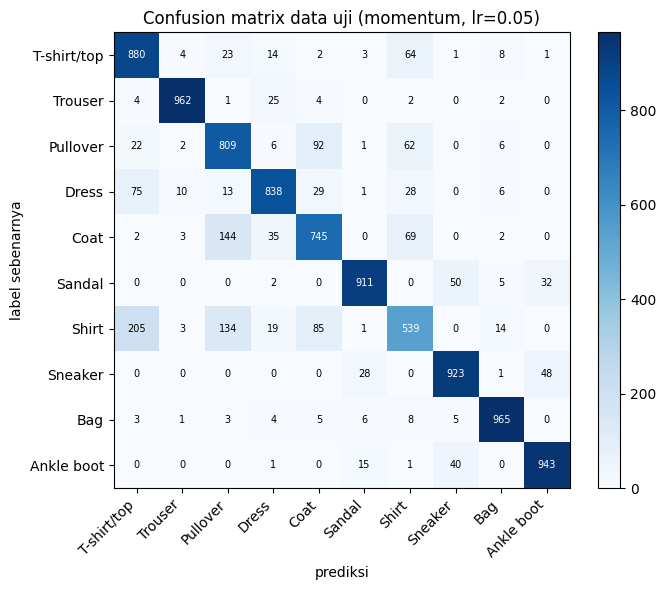

In [8]:
# Latih ulang konfigurasi final, lalu evaluasi ds_uji SATU KALI.
# Tampilkan confusion matrix dan sebutkan dua kelas yang paling sering tertukar.
from sklearn.metrics import confusion_matrix

final = pemenang.iloc[0]
OPT_BEST, LR_BEST = final['optimizer'], float(final['learning_rate'])
print(f"konfigurasi final: {OPT_BEST}, lr={LR_BEST:g} (val_loss={final['val_loss']:.4f})")

model_final, _, cat_final = jalankan(OPT_BEST, LR_BEST)
assert abs(cat_final['val_loss'] - final['val_loss']) < 1e-6, 'latih ulang harus mereproduksi run terpilih'

# Satu lintasan data uji untuk loss, akurasi, dan prediksi.
model_final.eval()
with torch.no_grad():
    logits_uji = torch.cat([model_final(xb.to(DEVICE)).cpu()
                            for xb, _ in loader(ds_uji, 512, False)])
test_loss = nn.functional.cross_entropy(logits_uji, y_uji).item()
pred_uji = logits_uji.argmax(1)
test_acc = (pred_uji == y_uji).float().mean().item()
print(f'test loss {test_loss:.4f}   test accuracy {test_acc:.4f}')

KELAS = uji_resmi.classes
cm = confusion_matrix(y_uji.numpy(), pred_uji.numpy())
salah = cm + cm.T
np.fill_diagonal(salah, 0)
i, j = np.unravel_index(salah.argmax(), salah.shape)
print(f'paling sering tertukar: {KELAS[i]} <-> {KELAS[j]} '
      f'({cm[i, j]} + {cm[j, i]} = {salah[i, j]} kesalahan)')

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(KELAS, rotation=45, ha='right')
ax.set_yticklabels(KELAS)
for r in range(10):
    for c in range(10):
        ax.text(c, r, cm[r, c], ha='center', va='center', fontsize=7,
                color='white' if cm[r, c] > cm.max() / 2 else 'black')
ax.set(title=f'Confusion matrix data uji ({OPT_BEST}, lr={LR_BEST:g})',
       xlabel='prediksi', ylabel='label sebenarnya')
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

idx_final = tabel.index[tabel['run_id'] == final['run_id']][0]
tabel.loc[idx_final, 'test_loss'] = test_loss
tabel.loc[idx_final, 'test_acc'] = test_acc

**Checkpoint menit ke-95.** Tunjukkan tabel sembilan run dan grafik tiga pemenang kepada asisten sebelum melanjutkan ke bagian F.

## F. Scheduler dan batch size - 15 poin

Enam run tambahan, seluruhnya memakai optimizer dan learning rate terbaik Anda.

In [9]:
# Tiga run scheduler (None, 'step', 'cosine') pada anggaran epoch yang sama,
# lalu tiga run batch size (32, 128, 512). Laporkan kolom n_update.
tambahan = []
for sch in [None, 'step', 'cosine']:
    _, _, cat = jalankan(OPT_BEST, LR_BEST, scheduler=sch)
    cat['run_id'] = f"F_sched_{sch or 'none'}"
    cat['notes'] = 'eksperimen scheduler'
    tambahan.append(cat)
for b in [32, 128, 512]:
    _, _, cat = jalankan(OPT_BEST, LR_BEST, batch=b)
    cat['run_id'] = f'F_batch_{b}'
    cat['notes'] = 'eksperimen batch size'
    tambahan.append(cat)

df_tambahan = pd.DataFrame(tambahan)
print(df_tambahan[['run_id', 'scheduler', 'batch_size', 'n_update',
                   'val_loss', 'val_acc', 'runtime_s']].to_string(index=False))
assert len(df_tambahan) == 6, 'harus ada enam run tambahan'

        run_id scheduler  batch_size  n_update  val_loss  val_acc  runtime_s
  F_sched_none      none         128       470    0.3988   0.8627     0.9993
  F_sched_step      step         128       470    0.3809   0.8667     1.0402
F_sched_cosine    cosine         128       470    0.3748   0.8707     0.9616
    F_batch_32      none          32      1875    0.6531   0.7853     2.4701
   F_batch_128      none         128       470    0.3988   0.8627     0.9918
   F_batch_512      none         512       120    0.4281   0.8503     0.6997


In [10]:
# Gabungkan seluruh run (baseline, sembilan run inti, enam run tambahan) ke satu metrics.csv.
semua = pd.concat([df_baseline, tabel, df_tambahan], ignore_index=True)
semua.insert(0, 'module', 'M03')
semua.insert(1, 'student_id', NIM)
semua.to_csv(f'M03_{NIM}_metrics.csv', index=False)
print(f'{len(semua)} baris tersimpan')
assert len(semua) >= 15, 'metrics.csv minimal berisi 15 run'

18 baris tersimpan


## G. Pertanyaan analisis - bagian dari 15 poin

1. Apakah optimizer dengan validation loss terendah juga yang tercepat? Tidak persis. Validation loss terendah diraih SGD+momentum $\eta=0{,}05$ (runtime 1,13 s). SGD biasa $\eta=0{,}1$ tercatat 1,12 s dan Adam $\eta=10^{-3}$ 1,22 s. Namun kesembilan run inti hanya berkisar 0,95-1,33 s di CPU, dan konfigurasi yang sama persis dengan pemenang (`F_sched_none`) tercatat 1,00 s, sehingga perbedaan waktu antaroptimizer masih dalam derau pengukuran. Bila "tercepat" diartikan tercepat konvergen per epoch, momentum dan Adam jelas unggul: setelah epoch 1 validation loss-nya 0,486 dan 0,509, sedangkan SGD terbaik masih 0,671.
2. Mengapa learning rate terbaik Adam jauh lebih kecil daripada SGD? Adam menormalkan gradien per parameter: $\Delta\theta \approx -\eta\,\hat m/\sqrt{\hat v}$. Rasio $\hat m/\sqrt{\hat v}$ berorde 1, sehingga setiap parameter bergerak kira-kira sebesar $\eta$ tanpa bergantung pada skala gradien. SGD bergerak sebesar $\eta\,g$, padahal gradien per parameter di sini sangat kecil. Dengan norma gradien global sekitar 1,3 yang tersebar pada 101.770 parameter, rata-ratanya sekitar $1{,}3/\sqrt{101\,770} \approx 0{,}004$. SGD dengan $\eta=0{,}1$ menghasilkan langkah sekitar $4\times10^{-4}$ per parameter, orde yang sama dengan Adam pada $\eta=10^{-3}$. Karena itu Adam membutuhkan learning rate sekitar 100 kali lebih kecil untuk besar langkah yang setara. Adam pada $\eta=10^{-2}$ sudah terlalu besar: validation loss-nya melonjak dari 0,431 ke 0,514 di epoch 3.
3. Apa yang terjadi saat learning rate terlalu besar, dan pada epoch keberapa gejalanya terlihat? Loss tidak turun monoton, melainkan berosilasi, karena langkahnya melompati minimum. Validation loss menjadi zig-zag dan menjauh dari train loss. Pada SGD $\eta=1{,}0$ gejala sudah terlihat sejak **epoch 1**: train loss 2,431 lebih buruk dari tebakan acak, dan pada epoch 3 validation loss naik ke 2,242. Pada SGD $\eta=0{,}5$ validation loss naik di **epoch 3** (0,535 ke 0,599) dan epoch 5 (0,494 ke 0,640) walaupun train loss terus turun. Momentum $\eta=0{,}1$, yang langkah efektifnya sekitar 10 kali lebih besar, naik mulai **epoch 4** (0,526 ke 0,572 ke 0,593). Adam $\eta=10^{-2}$ melonjak di **epoch 3**. Tidak ada run yang divergen menjadi `nan` pada grid ini, tetapi semuanya berakhir lebih buruk daripada learning rate yang lebih kecil.
4. Apakah scheduler memperbaiki hasil pada anggaran epoch yang sama? Bila tidak, mengapa? Ya, pada eksperimen ini scheduler memperbaiki hasil dengan anggaran yang sama (5 epoch, 470 update). Hasilnya: tanpa scheduler 0,3988 (akurasi 0,8627), StepLR 0,3809 (0,8667), dan cosine 0,3748 (0,8707). Tanpa scheduler, momentum $\eta=0{,}05$ masih berosilasi di sekitar minimum (validation loss naik 0,458 ke 0,483 di epoch 3). Menurunkan learning rate di epoch-epoch akhir memperkecil langkah, sehingga model dapat "mengendap" ke dasar lembah. Perbaikannya hanya sekitar 0,02 pada satu seed, sehingga masih perlu diuji dengan beberapa seed sebelum disimpulkan kuat.
5. Batch size mana yang Anda rekomendasikan bila anggaran diukur dalam **waktu**, bukan epoch? Saya merekomendasikan **batch 128**. Pada anggaran waktu, batch 512 paling hemat (120 update, 0,70 s), tetapi validation loss-nya 0,428. Batch 128 (470 update, 0,99 s) mencapai 0,399. Batch 32 (1.875 update, 2,47 s) justru paling lambat dan paling buruk (0,653), karena $\eta=0{,}05$ dengan momentum yang disetel untuk batch 128 menjadi terlalu berderau pada batch kecil. Batch 128 memberi validation loss terbaik dengan waktu sekitar 1,4 kali batch 512. Bila waktu sangat ketat, batch 512 dapat dipakai dengan menaikkan learning rate sebanding ukuran batch (*linear scaling rule*). Perlu dicatat, batch size di sini diuji tanpa menyetel ulang learning rate, sehingga hasil batch 32 tidak berarti batch kecil selalu buruk.

**Keterbatasan.** Modul ini memakai subset $12\,000$ citra dan $5$ epoch. Sebutkan apa yang tidak boleh disimpulkan dari hasil ini: Hasil ini berasal dari subset 12.000 citra, 5 epoch, satu seed (48), satu arsitektur MLP, dan CPU. Karena itu, yang **tidak boleh** disimpulkan: (1) bahwa SGD+momentum lebih baik daripada Adam secara umum, karena selisih 0,005 masih dalam variasi antar-seed yang tidak diukur; (2) bahwa learning rate terbaik di sini juga terbaik untuk 60.000 data atau pelatihan lebih lama, karena grid hanya tiga nilai per optimizer dan anggaran 5 epoch menguntungkan optimizer yang cepat di awal; (3) peringkat kecepatan optimizer, karena runtime sekitar 1 detik di CPU didominasi derau dan akan berbeda di GPU; (4) bahwa batch kecil selalu buruk, karena learning rate tidak disetel ulang per batch size; dan (5) bahwa akurasi uji 0,8515 mewakili kemampuan terbaik pada Fashion-MNIST, karena model yang lebih besar atau berbasis konvolusi dengan data penuh dapat jauh lebih tinggi.

## Checklist sebelum mengumpulkan

- [x] Identitas, seed, versi library, dan device tercantum.
- [x] Seluruh `TODO` dan `raise NotImplementedError` sudah diganti.
- [x] Split, normalisasi, dan jumlah parameter lolos sel pemeriksaan.
- [x] Seluruh run memanggil `jalankan()` yang sama.
- [x] `metrics.csv` memuat minimal 15 run, termasuk yang gagal.
- [x] Pemenang dipilih dari validation loss; data uji dipakai satu kali.
- [x] Grafik berlabel lengkap dan keterbatasan subset disebutkan.
- [x] Notebook lolos *Restart Kernel and Run All*.